In [1]:
import pandas as pd
import nltk
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nlp = spacy.load("en_core_web_sm")
print("All libraries loaded!")

[nltk_data] Downloading package punkt to C:\Users\Vradant
[nltk_data]     Sahal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Vradant
[nltk_data]     Sahal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Vradant
[nltk_data]     Sahal\AppData\Roaming\nltk_data...


All libraries loaded!


In [2]:
df = pd.read_csv("../data/raw/grievances.csv")
print("Shape:", df.shape)
print("\nDepartment counts:")
print(df['department'].value_counts())
df.head()

Shape: (20, 4)

Department counts:
department
Roads           5
Water Supply    4
Electricity     4
Sanitation      4
Transport       3
Name: count, dtype: int64


,complaint,department,sentiment,urgency
0,Water supply has been cut off for 3 days in ou...,Water Supply,Negative,High
1,"No electricity since yesterday evening, please...",Electricity,Negative,High
2,Large pothole on main road causing accidents d...,Roads,Negative,Medium
3,"Garbage not collected for 2 weeks, foul smell ...",Sanitation,Negative,Medium
4,"Bus number 42 never arrives on time, daily pro...",Transport,Negative,Low


In [5]:
import re
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['cleaned'] = df['complaint'].apply(clean_text)
print("Sample cleaned text:")
print(df[['complaint','cleaned']].head(3))

Sample cleaned text:
                                           complaint  \
0  Water supply has been cut off for 3 days in ou...   
1  No electricity since yesterday evening, please...   
2  Large pothole on main road causing accidents d...   

                                             cleaned  
0                          water supply cut day area  
1  electricity since yesterday evening please fix...  
2     large pothole main road causing accident daily  


In [4]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Vradant
[nltk_data]     Sahal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

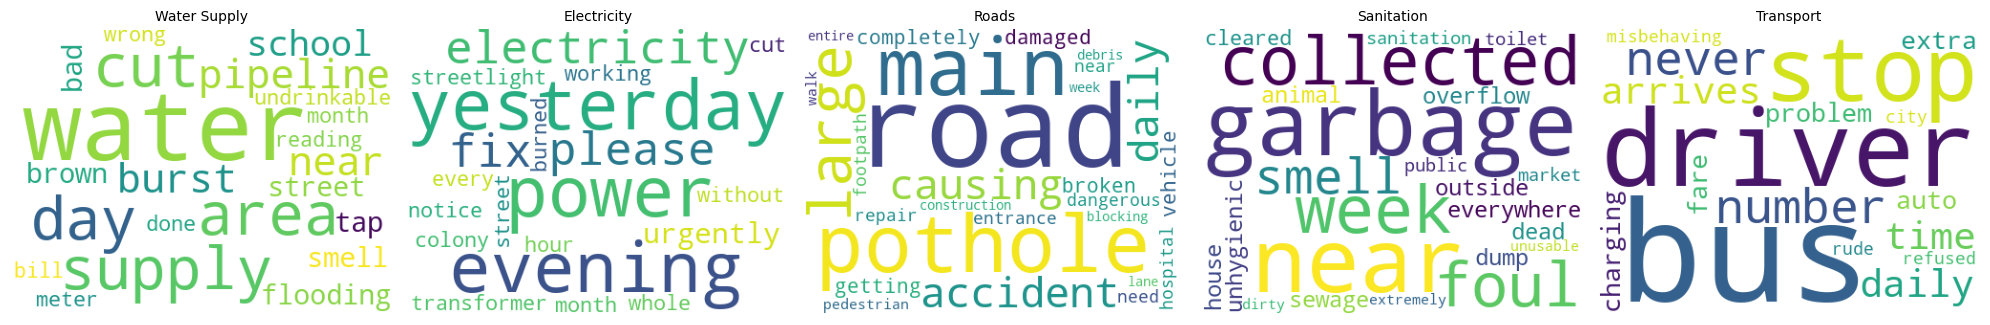

WordCloud saved to docs/


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
departments = df['department'].unique()

for i, dept in enumerate(departments):
    text = ' '.join(df[df['department'] == dept]['cleaned'])
    wc = WordCloud(width=400, height=300, background_color='white').generate(text)
    axes[i].imshow(wc)
    axes[i].set_title(dept, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("../docs/wordcloud.png")
plt.show()
print("WordCloud saved to docs/")

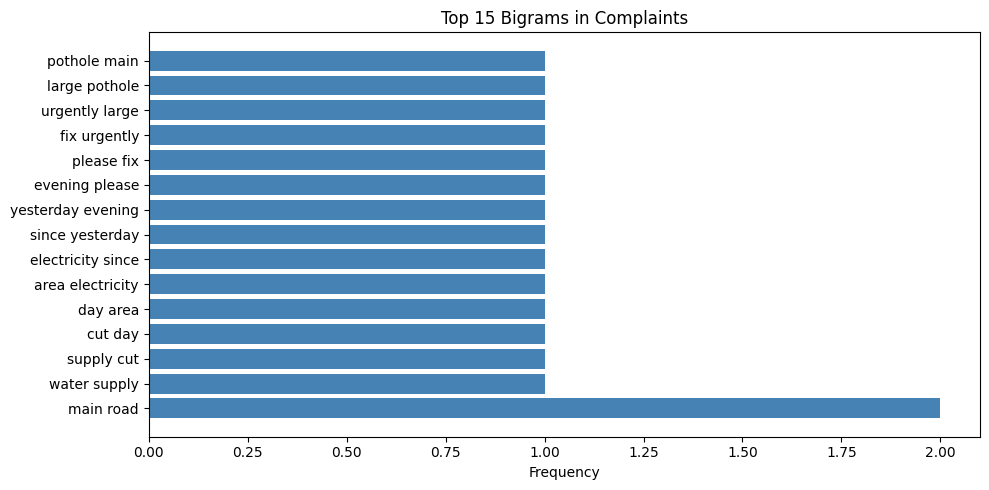

In [7]:
from nltk.util import ngrams

all_words = ' '.join(df['cleaned']).split()
bigrams = list(ngrams(all_words, 2))
bigram_freq = Counter(bigrams).most_common(15)

labels = [' '.join(b) for b, c in bigram_freq]
counts = [c for b, c in bigram_freq]

plt.figure(figsize=(10, 5))
plt.barh(labels, counts, color='steelblue')
plt.title("Top 15 Bigrams in Complaints")
plt.xlabel("Frequency")
plt.tight_layout()
plt.savefig("../docs/bigrams.png")
plt.show()

In [8]:
df.to_csv("../data/processed/grievances_cleaned.csv", index=False)
print("Cleaned dataset saved! Shape:", df.shape)
print(df[['complaint','cleaned','department']].head())

Cleaned dataset saved! Shape: (20, 5)
                                           complaint  \
0  Water supply has been cut off for 3 days in ou...   
1  No electricity since yesterday evening, please...   
2  Large pothole on main road causing accidents d...   
3  Garbage not collected for 2 weeks, foul smell ...   
4  Bus number 42 never arrives on time, daily pro...   

                                             cleaned    department  
0                          water supply cut day area  Water Supply  
1  electricity since yesterday evening please fix...   Electricity  
2     large pothole main road causing accident daily         Roads  
3       garbage collected week foul smell everywhere    Sanitation  
4        bus number never arrives time daily problem     Transport  
